In [1]:
import numpy as np
import pandas as pd
import bilby

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib import colors
from matplotlib.legend_handler import HandlerPatch
from matplotlib import rc
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18

In [2]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [3]:
data_HI = bilby.result.read_in_result('../../results/cosmoPEs_snr150_rs1_nside16_HIHI/label_result.json')
data_NoHI = bilby.result.read_in_result('../../results/cosmoPEs_snr150_rs1_nside16_HINoHI/label_result.json')

In [4]:
class DiagonalPatchHandler(HandlerPatch):
    def __init__(self, color1, color2, **kwargs):
        self.color1 = color1
        self.color2 = color2
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                        xdescent, ydescent, width, height, fontsize, trans):
        
        # Triangle 1 (bottom-left to top-right diagonal)
        tri1 = mpatches.Polygon(
            [[xdescent, ydescent],
             [xdescent + width, ydescent],
             [xdescent, ydescent + height]],
            facecolor=self.color1,
            transform=trans
        )

        # Triangle 2
        tri2 = mpatches.Polygon(
            [[xdescent + width, ydescent],
             [xdescent + width, ydescent + height],
             [xdescent, ydescent + height]],
            facecolor=self.color2,
            transform=trans
        )

        return [tri1, tri2]


In [5]:
class HorizontalLinesHandler(HandlerBase):
    def __init__(self, color1, color2, lw=2.0, sep=0.48):
        self.color1 = color1
        self.color2 = color2
        self.lw = lw
        self.sep = sep
        super().__init__()

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        y1 = ydescent + height * (0.5 - self.sep / 2)
        y2 = ydescent + height * (0.5 + self.sep / 2)

        line1 = Line2D(
            [xdescent, xdescent + width],
            [y1, y1],
            color=self.color1,
            lw=self.lw,
            transform=trans
        )

        line2 = Line2D(
            [xdescent, xdescent + width],
            [y2, y2],
            color=self.color2,
            lw=self.lw,
            transform=trans
        )

        return [line1, line2]

In [6]:
def color_to_hex_with_alpha(color_input, opacity):
    """
    Convert a color (hex or name) + opacity (0.0–1.0)
    into HEX with alpha (#RRGGBBAA)
    """

    if not (0.0 <= opacity <= 1.0):
        raise ValueError("Opacity must be between 0.0 and 1.0")

    # Convert color name or hex to RGB (0–1 range)
    r, g, b = colors.to_rgb(color_input)

    # Convert to 0–255
    r, g, b = int(r * 255), int(g * 255), int(b * 255)

    # Convert opacity to alpha
    alpha = round(opacity * 255)

    return "#{:02X}{:02X}{:02X}{:02X}".format(r, g, b, alpha)

In [7]:
H0_samples = data_HI.posterior['H0']     # km/s/Mpc
Om_samples = data_HI.posterior['Om0']     # dimensionless

H0_samples_noHI = data_NoHI.posterior['H0']     # km/s/Mpc
Om_samples_noHI = data_NoHI.posterior['Om0']     # dimensionless

# Redshift grid
#z = np.linspace(0, 4, len(H0_samples))
z = np.linspace(0, 4, 1_000)

# Compute H(z) for every posterior sample
# Shape: (nsamples, nz)
Hz_samples = H0_samples[:, None] * np.sqrt(
    Om_samples[:, None] * (1 + z[None, :])**3 + (1 - Om_samples[:, None])
)
Hz_samples_noHI = H0_samples_noHI[:, None] * np.sqrt(
    Om_samples_noHI[:, None] * (1 + z[None, :])**3 + (1 - Om_samples_noHI[:, None])
)
H0_prior = np.random.uniform(10, 240, len(H0_samples))
Om0_prior = np.random.uniform(0.1, 0.9, len(H0_samples))
Hz_samples_prior = H0_prior[:, None] * np.sqrt(
    Om0_prior[:, None] * (1 + z[None, :])**3 + (1 - Om0_prior[:, None])
)
# Summary statistics
Hz_inferred = 65.7*np.ones_like(z) * np.sqrt(0.4*np.ones_like(z) * (1 + z[None, :])**3 + (1 - 0.4*np.ones_like(z)))
Hz_injected = 67.7*np.ones_like(z) * np.sqrt(0.308*np.ones_like(z) * (1 + z[None, :])**3 + (1 - 0.308*np.ones_like(z)))
Hz_med = np.percentile(Hz_samples, 50, axis=0)
Hz_lo_68 = np.percentile(Hz_samples, 16, axis=0)
Hz_hi_68 = np.percentile(Hz_samples, 84, axis=0)
Hz_lo_95 = np.percentile(Hz_samples, 2.5, axis=0)
Hz_hi_95 = np.percentile(Hz_samples, 97.5, axis=0)

Hz_lo_68_noHI = np.percentile(Hz_samples_noHI, 16, axis=0)
Hz_hi_68_noHI = np.percentile(Hz_samples_noHI, 84, axis=0)
Hz_lo_95_noHI = np.percentile(Hz_samples_noHI, 2.5, axis=0)
Hz_hi_95_noHI = np.percentile(Hz_samples_noHI, 97.5, axis=0)



# Summary statistics for prior
Hz_med_prior = np.percentile(Hz_samples_prior, 50, axis=0)
Hz_lo_68_prior = np.percentile(Hz_samples_prior, 16, axis=0)
Hz_hi_68_prior = np.percentile(Hz_samples_prior, 84, axis=0)
Hz_lo_95_prior = np.percentile(Hz_samples_prior, 2.5, axis=0)
Hz_hi_95_prior = np.percentile(Hz_samples_prior, 97.5, axis=0)


Hz_lo_95 = np.ravel(Hz_lo_95)
Hz_hi_95 = np.ravel(Hz_hi_95)
Hz_lo_68 = np.ravel(Hz_lo_68)
Hz_hi_68 = np.ravel(Hz_hi_68)
Hz_med = np.ravel(Hz_med)

Hz_lo_95_noHI = np.ravel(Hz_lo_95_noHI)
Hz_hi_95_noHI = np.ravel(Hz_hi_95_noHI)
Hz_lo_68_noHI = np.ravel(Hz_lo_68_noHI)
Hz_hi_68_noHI = np.ravel(Hz_hi_68_noHI)

Hz_lo_95_prior = np.ravel(Hz_lo_95_prior) / (1 + z)
Hz_hi_95_prior = np.ravel(Hz_hi_95_prior) / (1 + z)
Hz_lo_68_prior = np.ravel(Hz_lo_68_prior) / (1 + z)
Hz_hi_68_prior = np.ravel(Hz_hi_68_prior) / (1 + z)
Hz_med_prior = np.ravel(Hz_med_prior) / (1 + z)


z = np.ravel(z)

Hz1pz_lo_95 = Hz_lo_95 / (1 + z)
Hz1pz_hi_95 = Hz_hi_95 / (1 + z)

Hz1pz_lo_68 = Hz_lo_68 / (1 + z)
Hz1pz_hi_68 = Hz_hi_68 / (1 + z)

Hz1pz_lo_95_noHI = Hz_lo_95_noHI / (1 + z)
Hz1pz_hi_95_noHI = Hz_hi_95_noHI / (1 + z)

Hz1pz_lo_68_noHI = Hz_lo_68_noHI / (1 + z)
Hz1pz_hi_68_noHI = Hz_hi_68_noHI / (1 + z)

Hz1pz_med   = Hz_med   / (1 + z)
Hz1pz_inferred = np.ravel(Hz_inferred) / (1 + z)
Hz1pz_injected = np.ravel(Hz_injected) / (1 + z)

/var/folders/v7/nz73c0sd1r3610zffg1d_w980000gq/T/ipykernel_44119/4180743710.py:13: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  Hz_samples = H0_samples[:, None] * np.sqrt(
/var/folders/v7/nz73c0sd1r3610zffg1d_w980000gq/T/ipykernel_44119/4180743710.py:14: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  Om_samples[:, None] * (1 + z[None, :])**3 + (1 - Om_samples[:, None])
/var/folders/v7/nz73c0sd1r3610zffg1d_w980000gq/T/ipykernel_44119/4180743710.py:16: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  Hz_samples_noHI = H0_samples_noHI[:, None] * np.sqrt(
/var/folders/v7/nz73c0sd1r3610z

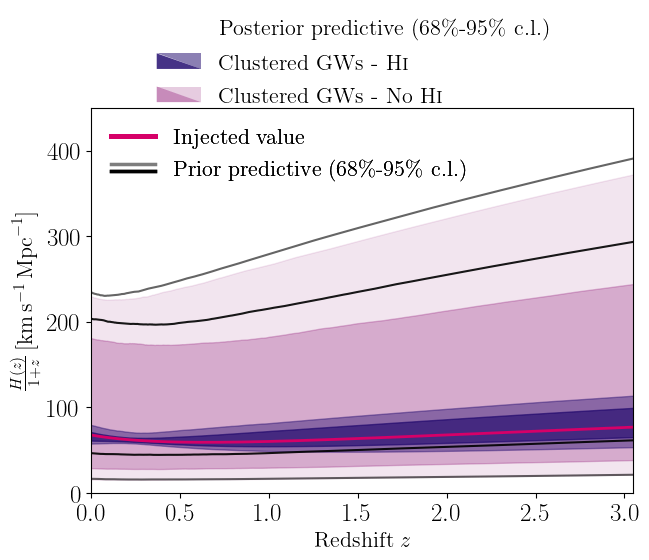

In [8]:
# Dummy handler: draws nothing, used for a legend "title" row
class InvisibleHandler(HandlerBase):
    def create_artists(
        self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans
    ):
        line = Line2D([], [], linestyle="None")
        line.set_visible(False)
        line.set_transform(trans)
        return [line]


figure = plt.figure(figsize=(7, 5))
ax = plt.gca()

# Prior predictive
plt.plot(z, Hz_lo_95_prior, alpha=0.6, color="black")
plt.plot(z, Hz_hi_95_prior, alpha=0.6, color="black")
plt.plot(z, Hz_lo_68_prior, alpha=0.9, color="black")
plt.plot(z, Hz_hi_68_prior, alpha=0.9, color="black")

# Posterior predictive: NO HI
plt.fill_between(
    z, Hz1pz_lo_68_noHI, Hz1pz_hi_68_noHI,
    alpha=0.25, color=ska_color_intermediate
)
plt.fill_between(
    z, Hz1pz_lo_95_noHI, Hz1pz_hi_95_noHI,
    alpha=0.1, color=ska_color_intermediate
)


# Injected value
plt.plot(z, Hz1pz_injected, lw=2, color=ska_color_pink, linestyle="solid")

# Posterior predictive: HI
plt.fill_between(
    z, Hz1pz_lo_68, Hz1pz_hi_68,
    alpha=0.6, color=ska_color_purple
)
plt.fill_between(
    z, Hz1pz_lo_95, Hz1pz_hi_95,
    alpha=0.4, color=ska_color_purple
)

plt.xlabel(r"\rm Redshift $z$", fontsize=16)
plt.ylabel(
    r"$\frac{H(z)}{1+z}\,[\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}]$",
    fontsize=16
)

prior_patch = mpatches.Rectangle((0, 0), 1, 1)
patch_HIHI = mpatches.Rectangle((0, 0), 1, 1)
patch_HINOHI = mpatches.Rectangle((0, 0), 1, 1)
posterior_title = Line2D([], [], linestyle="None")


legend1_elements = [
    Line2D(
        [0], [0],
        color=ska_color_pink,
        lw=3.5,
        linestyle="solid"
    ),
    prior_patch,
]

legend1_labels = [
    r"\rm Injected value",
    r"\rm Prior predictive ($68\%$-$95\%$ c.l.)",
]

leg1 = ax.legend(
    legend1_elements,
    legend1_labels,
    loc="upper left",
    fontsize=16,
    frameon=False,
    handler_map={
        prior_patch: HorizontalLinesHandler(
            color_to_hex_with_alpha("black", 0.9),
            color_to_hex_with_alpha("black", 0.3),
            lw=2.5
        ),
    },
)

# Keep legend 1 when adding legend 2
ax.add_artist(leg1)


legend2_elements = [
    posterior_title,
    patch_HIHI,
    patch_HINOHI,
]

legend2_labels = [
    r"\rm Posterior predictive ($68\%$-$95\%$ c.l.)",
    r"\rm \quad Clustered GWs - {\textrm{H\textsc{i}}}",
    r"\rm \quad Clustered GWs - No {\textrm{H\textsc{i}}}",
]

figure.legend(
    legend2_elements,
    legend2_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=1,
    fontsize=16,
    frameon=False,
    labelspacing=0.6,
    handletextpad=0.8,
    handler_map={
        posterior_title: InvisibleHandler(),
        patch_HIHI: DiagonalPatchHandler(
            color_to_hex_with_alpha(ska_color_purple, 0.8),
            color_to_hex_with_alpha(ska_color_purple, 0.5),
        ),
        patch_HINOHI: DiagonalPatchHandler(
            color_to_hex_with_alpha(ska_color_intermediate, 0.45),
            color_to_hex_with_alpha(ska_color_intermediate, 0.2),
        ),
    },
)

plt.xlim(0, 3.05)
plt.ylim(0, 450)

plt.savefig(
    "h_of_z_prior_and_posterior.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [9]:
width_68 = Hz1pz_hi_68 - Hz1pz_lo_68
i_best_68 = np.argmin(width_68)

z_best_68 = z[i_best_68]
q_best_68 = Hz1pz_med[i_best_68]
w_best_68 = width_68[i_best_68]

print("Tightest 68% constraint at:")
print("z =", z_best_68)
print("median =", q_best_68)
print("68% width =", w_best_68)
print("68% interval =", Hz1pz_lo_68[i_best_68], Hz1pz_hi_68[i_best_68])

Tightest 68% constraint at:
z = 0.22022022022022023
median = 61.45494552848931
68% width = 4.797017157759726
68% interval = 59.35305435834775 64.15007151610747
